In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")


# Basic Statistics - 2

## Objective

The objective of this assignment is to analyze hospital patient and billing data, clean and prepare the datasets, handle missing and duplicate records, calculate department-wise billing, and combine patient and billing information for further analysis.

In [2]:
# Load the patient dataset
patient_df = pd.read_csv("Patient_Data.csv")

# Display the first 5 rows
patient_df.head()

,PatientID,Name,Department,Doctor,BillAmount,ReceptionistID,CheckInTime
0,101,Alice,Cardiology,Dr. Smith,5000.00,1,2023-01-10 09:00
1,102,Bob,Neurology,Dr. John,NaN,2,2023-01-11 10:30
2,103,Charlie,Orthopedics,Dr. Lee,7500.00,1,2023-01-12 11:00
3,104,David,Cardiology,Dr. Smith,6200.00,3,2023-01-13 12:00
4,105,Eva,Dermatology,Dr. Rose,NaN,2,2023-01-14 08:45


In [3]:
# Display dataset information
patient_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PatientID       6 non-null      int64  
 1   Name            6 non-null      str    
 2   Department      6 non-null      str    
 3   Doctor          6 non-null      str    
 4   BillAmount      4 non-null      float64
 5   ReceptionistID  6 non-null      int64  
 6   CheckInTime     6 non-null      str    
dtypes: float64(1), int64(2), str(4)
memory usage: 468.0 bytes


## 1. Load Patient Dataset and Summary

## 2. Select Relevant Billing Columns

In [4]:
# Select columns relevant for billing
billing_columns = patient_df[['PatientID', 'Department', 'Doctor', 'BillAmount']]

billing_columns

,PatientID,Department,Doctor,BillAmount
0,101,Cardiology,Dr. Smith,5000.00
1,102,Neurology,Dr. John,NaN
2,103,Orthopedics,Dr. Lee,7500.00
3,104,Cardiology,Dr. Smith,6200.00
4,105,Dermatology,Dr. Rose,NaN
5,101,Cardiology,Dr. Smith,5000.00


## 3. Remove Administrative Columns

In [5]:
# Remove administrative columns
patient_cleaned = patient_df.drop(columns=['ReceptionistID', 'CheckInTime'])

patient_cleaned

,PatientID,Name,Department,Doctor,BillAmount
0,101,Alice,Cardiology,Dr. Smith,5000.00
1,102,Bob,Neurology,Dr. John,NaN
2,103,Charlie,Orthopedics,Dr. Lee,7500.00
3,104,David,Cardiology,Dr. Smith,6200.00
4,105,Eva,Dermatology,Dr. Rose,NaN
5,101,Alice,Cardiology,Dr. Smith,5000.00


## 4. Total Bill Amount by Department

In [6]:
# Calculate total bill amount for each department
department_billing = patient_cleaned.groupby('Department')['BillAmount'].sum()

department_billing

Department
Cardiology    16200.00
Dermatology       0.00
Neurology         0.00
Orthopedics    7500.00
Name: BillAmount, dtype: float64

## 5. Remove Duplicate Patient Records

In [7]:
# Remove duplicate patient records based on PatientID
patient_unique = patient_cleaned.drop_duplicates(
    subset='PatientID',
    keep='first'
)

patient_unique

,PatientID,Name,Department,Doctor,BillAmount
0,101,Alice,Cardiology,Dr. Smith,5000.00
1,102,Bob,Neurology,Dr. John,NaN
2,103,Charlie,Orthopedics,Dr. Lee,7500.00
3,104,David,Cardiology,Dr. Smith,6200.00
4,105,Eva,Dermatology,Dr. Rose,NaN


In [8]:
# Check the number of records after removing duplicates
print("Number of records before removing duplicates:", len(patient_cleaned))
print("Number of records after removing duplicates:", len(patient_unique))

Number of records before removing duplicates: 6
Number of records after removing duplicates: 5


## 6. Handle Missing Bill Amounts

In [10]:
# Check missing BillAmount values
print("Missing BillAmount values:", patient_unique['BillAmount'].isna().sum())

Missing BillAmount values: 2


In [11]:
# Fill missing BillAmount values with the median
bill_median = patient_unique['BillAmount'].median()

patient_unique['BillAmount'] = patient_unique['BillAmount'].fillna(bill_median)

print("Median BillAmount:", bill_median)
patient_unique

Median BillAmount: 6200.0


,PatientID,Name,Department,Doctor,BillAmount
0,101,Alice,Cardiology,Dr. Smith,5000.00
1,102,Bob,Neurology,Dr. John,6200.00
2,103,Charlie,Orthopedics,Dr. Lee,7500.00
3,104,David,Cardiology,Dr. Smith,6200.00
4,105,Eva,Dermatology,Dr. Rose,6200.00


## 7. Verify Cleaned Patient Dataset

In [13]:
# Verify missing values after cleaning
print("Missing values after cleaning:")
print(patient_unique.isnull().sum())

print("\nFinal cleaned dataset:")
patient_unique

Missing values after cleaning:
PatientID     0
Name          0
Department    0
Doctor        0
BillAmount    0
dtype: int64

Final cleaned dataset:


,PatientID,Name,Department,Doctor,BillAmount
0,101,Alice,Cardiology,Dr. Smith,5000.00
1,102,Bob,Neurology,Dr. John,6200.00
2,103,Charlie,Orthopedics,Dr. Lee,7500.00
3,104,David,Cardiology,Dr. Smith,6200.00
4,105,Eva,Dermatology,Dr. Rose,6200.00


## 8. Department-wise Billing Analysis

In [14]:
# Calculate total and average bill amount by department
department_summary = patient_unique.groupby('Department')['BillAmount'].agg(
    Total_Bill='sum',
    Average_Bill='mean'
).reset_index()

department_summary

,Department,Total_Bill,Average_Bill
0,Cardiology,11200.00,5600.00
1,Dermatology,6200.00,6200.00
2,Neurology,6200.00,6200.00
3,Orthopedics,7500.00,7500.00


## 9. Department-wise Billing Visualization

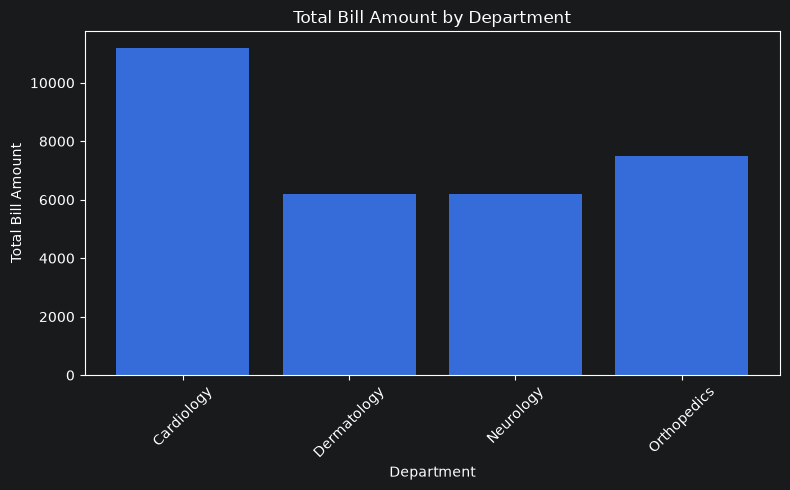

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    department_summary['Department'],
    department_summary['Total_Bill']
)

plt.title('Total Bill Amount by Department')
plt.xlabel('Department')
plt.ylabel('Total Bill Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. Identify Highest Billing Department

In [16]:
# Identify the department with the highest total billing
highest_billing = department_summary.loc[
    department_summary['Total_Bill'].idxmax()
]

print("Department with highest total billing:", highest_billing['Department'])
print("Total billing amount:", highest_billing['Total_Bill'])

Department with highest total billing: Cardiology
Total billing amount: 11200.0


## 11. Save Cleaned Patient Dataset

In [17]:
# Save the cleaned patient dataset
patient_unique.to_csv("cleaned_patient_data.csv", index=False)

print("Cleaned patient dataset saved successfully.")

Cleaned patient dataset saved successfully.


## 12. Final Summary and Findings

### Key Findings

- The original patient dataset contained 6 records.
- One duplicate patient record was identified and removed, leaving 5 unique patients.
- Two missing BillAmount values were identified.
- The missing BillAmount values were replaced using the median bill amount of 6200.
- After cleaning, there were no missing values in the final dataset.
- Cardiology had the highest total billing amount of 11200.
- Orthopedics had the second-highest total billing amount of 7500.
- Dermatology and Neurology each had total billing of 6200.
- The cleaned patient dataset was saved as `cleaned_patient_data.csv`.

### Conclusion

The patient and billing data were successfully cleaned and analyzed. Duplicate records were removed, missing billing values were handled using the median, and department-wise billing was calculated and visualized. Cardiology generated the highest total billing among the departments. The final cleaned dataset was saved for further analysis.